# 05 · Outbreak investigation: counts, rates, uncertainty

**Mission:** build an epidemic curve and choropleth, compare denominators, and test reporting assumptions. Allow 45 minutes. Prerequisite: Lab 00.

**Run:** choose the Python (Pyodide) kernel in JupyterLite, then Run → Run All Cells. First use downloads Matplotlib. All training data are **SYNTHETIC** unless explicitly labeled LIVE. Downloads appear below and in `exports/`; the browser filesystem is separate from your computer. Each lab runs independently.

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("matplotlib")
import json, math
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from worldview_lab import (load, export, map_layer, chart_style, haversine_km,
    wilson_interval, shortest_times, freshness, normalize_quakes,
    validate_geojson, brief_request, validate_brief)
chart_style()

## Define the quantity before mapping it

The fixture contains 14-day **new cases**, with one case per fictional person, and a fixed resident population. `cases / population × 100,000` is a scaled **cumulative incidence proportion** for this interval. The short column name `rate_per_100k` is retained for map interoperability; this is not a person-time incidence rate. No claim about a real outbreak is made.

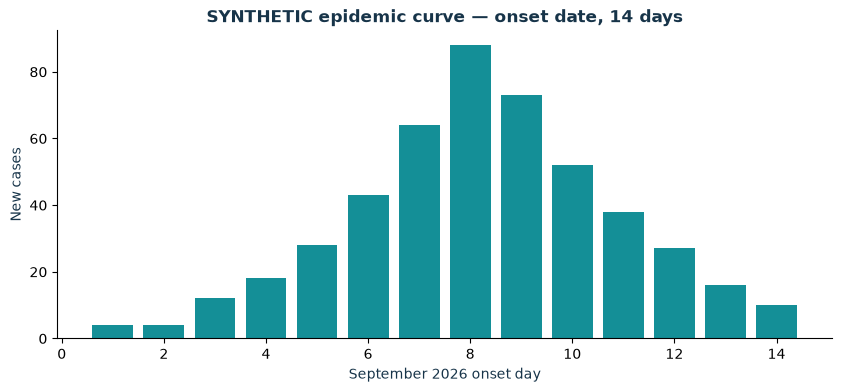

In [2]:
districts=load('districts.geojson');p=[f['properties'] for f in districts['features']]
daily=load('daily_cases.json')
days=sorted({r['onset_date'] for r in daily})
counts=[sum(r['cases'] for r in daily if r['onset_date']==day) for day in days]
assert sum(counts)==sum(r['cases'] for r in p)
fig,ax=plt.subplots();ax.bar(range(1,15),counts);ax.set(xlabel='September 2026 onset day',ylabel='New cases',title='SYNTHETIC epidemic curve — onset date, 14 days');plt.show()

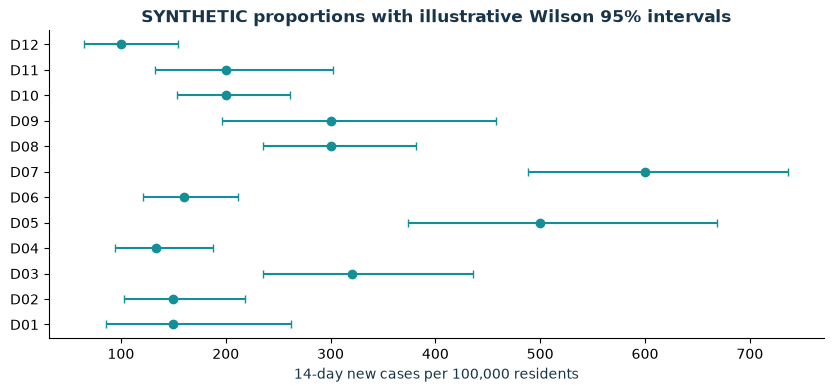

<iframe title="SYNTHETIC teaching layer" sandbox="allow-scripts" style="width:100%;height:470px;border:0" srcdoc="<!doctype html><html lang="en"><meta charset="utf-8"><link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css">
 <style>body{margin:0;font:14px system-ui}#map{height:420px}header{padding:10px;background:#102536;color:#fff}</style>
 <header>SYNTHETIC teaching layer | cyan &lt;200 · amber 200–399 · coral ≥400 per 100k (when rate is selected)</header><div id="map"></div>
 <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script><script>
 const data={"type": "FeatureCollection", "features": [{"type": "Feature", "id": "D01", "properties": {"id": "D01", "name": "Exercise district 01", "population": 8000, "cases": 12, "rate_per_100k": 150.0, "reporting_fraction": 1.0, "longitude": -77.235, "latitude": 38.71, "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T12:00:00Z", "status": "SIMULATED", "height_m": 750}, "geometry": {"type": "Polygon", "coordinates": [[[-77.3, 38.65], [-77.17999999999999, 38.65], [-77.17999999999999, 38.76], [-77.3, 38.76], [-77.3, 38.65]]]}}, {"type": "Feature", "id": "D02", "properties": {"id": "D02", "name": "Exercise district 02", "population": 18000, "cases": 27, "rate_per_100k": 150.0, "reporting_fraction": 0.85, "longitude": -77.105, "latitude": 38.71, "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T12:00:00Z", "status": "SIMULATED", "height_m": 750}, "geometry": {"type": "Polygon", "coordinates": [[[-77.17, 38.65], [-77.05, 38.65], [-77.05, 38.76], [-77.17, 38.76], [-77.17, 38.65]]]}}, {"type": "Feature", "id": "D03", "properties": {"id": "D03", "name": "Exercise district 03", "population": 12500, "cases": 40, "rate_per_100k": 320.0, "reporting_fraction": 0.7, "longitude": -76.975, "latitude": 38.71, "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T12:00:00Z", "status": "SIMULATED", "height_m": 1600}, "geometry": {"type": "Polygon", "coordinates": [[[-77.03999999999999, 38.65], [-76.91999999999999, 38.65], [-76.91999999999999, 38.76], [-77.03999999999999, 38.76], [-77.03999999999999, 38.65]]]}}, {"type": "Feature", "id": "D04", "properties": {"id": "D04", "name": "Exercise district 04", "population": 24000, "cases": 32, "rate_per_100k": 133.33333333333334, "reporting_fraction": 1.0, "longitude": -76.845, "latitude": 38.71, "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T12:00:00Z", "status": "SIMULATED", "height_m": 667}, "geometry": {"type": "Polygon", "coordinates": [[[-76.91, 38.65], [-76.78999999999999, 38.65], [-76.78999999999999, 38.76], [-76.91, 38.76], [-76.91, 38.65]]]}}, {"type": "Feature", "id": "D05", "properties": {"id": "D05", "name": "Exercise district 05", "population": 9000, "cases": 45, "rate_per_100k": 500.0, "reporting_fraction": 0.85, "longitude": -77.235, "latitude": 38.83, "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T12:00:00Z", "status": "SIMULATED", "height_m": 2500}, "geometry": {"type": "Polygon", "coordinates": [[[-77.3, 38.769999999999996], [-77.17999999999999, 38.769999999999996], [-77.17999999999999, 38.879999999999995], [-77.3, 38.879999999999995], [-77.3, 38.769999999999996]]]}}, {"type": "Feature", "id": "D06", "properties": {"id": "D06", "name": "Exercise district 06", "population": 30000, "cases": 48, "rate_per_100k": 160.0, "reporting_fraction": 0.7, "longitude": -77.105, "latitude": 38.83, "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T12:00:00Z", "status": "SIMULATED", "height_m": 800}, "geometry": {"type": "Polygon", "coordinates": [[[-77.17, 38.769999999999996], [-77.05, 38.769999999999996], [-77.05, 38.879999999999995], [-77.17, 38.879999999999995], [-77.17, 38.769999999999996]]]}}, {"type": "Feature", "id": "D07", "properties": {"id": "D07", "name": "Exercise district 07", "population": 15000, "cases": 90, "rate_per_100k": 600.0, "reporting_fraction": 1.0, "longitude": -76.975, "latitude": 38.83, "source": "SYNTHETIC exercise v1", "

In [3]:
rates=[r['cases']/r['population']*100000 for r in p]
intervals=[wilson_interval(r['cases'],r['population']) for r in p]
fig,ax=plt.subplots()
ax.errorbar(rates,[r['id'] for r in p],xerr=[[v-lo for v,(lo,hi) in zip(rates,intervals)], [hi-v for v,(lo,hi) in zip(rates,intervals)]],fmt='o',capsize=3)
ax.set(xlabel='14-day new cases per 100,000 residents',title='SYNTHETIC proportions with illustrative Wilson 95% intervals');plt.show()
map_layer(districts)

The intervals assume independent binomial outcomes and a complete denominator. They do **not** capture spatial dependence, under-ascertainment, reporting delays, or errors in population estimates. These teaching assumptions are usually incomplete in surveillance data. A cluster of colors is not a statistically established hotspot or a causal mechanism.

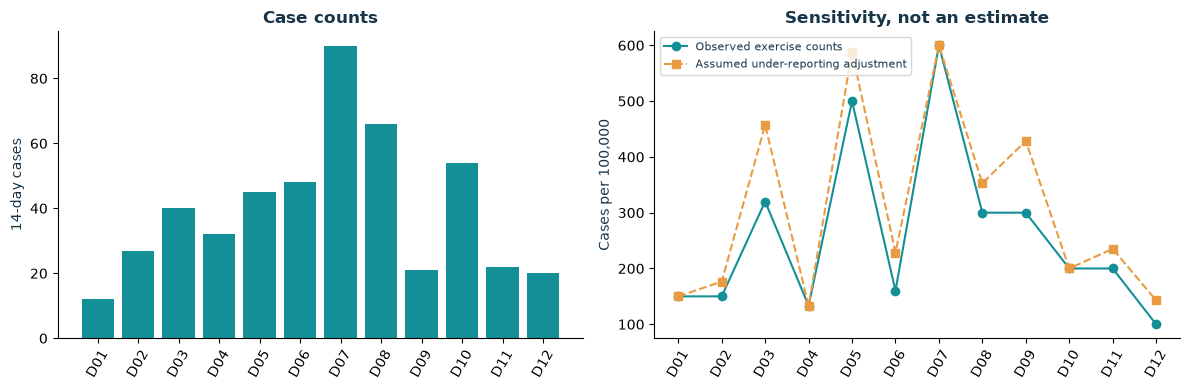

WindowsPath('exports/outbreak.geojson')

In [4]:
fig,axs=plt.subplots(1,2,figsize=(12,4))
axs[0].bar([r['id'] for r in p],[r['cases'] for r in p]);axs[0].set(title='Case counts',ylabel='14-day cases')
adjusted=[v/r['reporting_fraction'] for v,r in zip(rates,p)]
axs[1].plot([r['id'] for r in p],rates,'o-',label='Observed exercise counts')
axs[1].plot([r['id'] for r in p],adjusted,'s--',label='Assumed under-reporting adjustment')
axs[1].set(title='Sensitivity, not an estimate',ylabel='Cases per 100,000');axs[1].legend(fontsize=8)
for ax in axs:ax.tick_params(axis='x',rotation=60)
fig.tight_layout();plt.show()
export('outbreak.geojson',districts)

## Lab challenge

Change one district denominator by ±20%. Compare count ranking, normalized ranking, and interval width. Explain why report-date and onset-date curves answer different questions. **Checkpoint:** D07 has the most cases and the highest scaled proportion in this fixture, but D05 exceeds several higher-count districts after normalization.

**Astra prompt:** “Use only the attached chart and definitions. Explain counts versus cumulative incidence in plain language, identify denominator and reporting biases, and propose verification questions. Avoid causal or individual-level inference.”

## Sources and attribution

[CDC: Describing epidemiologic data](https://www.cdc.gov/field-epi-manual/php/chapters/describing-epi-data.html) covers time, place, person, and visual interpretation. [NIST: binomial proportion intervals](https://www.itl.nist.gov/div898/handbook/prc/section2/prc241.htm) describes Wilson intervals.

World View inspiration: [Kevin (Khoa) To, MIT](https://github.com/kevtoe/worldview). Original lab code, figures, and synthetic fixtures: JupyterLite WorldView contributors, MIT. See the [book references](https://jltobias.github.io/JupyterLite-WorldView/book/references.html) and repository notices for dependency and service terms.